# EcoWatt AI

## Exploratory Data Analysis (EDA)

### Step 1: Load the Dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "../dataset/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
import sys
print(sys.executable)

d:\EcoWatt-AI\venv\Scripts\python.exe


In [4]:
import sys
print(sys.executable)

d:\EcoWatt-AI\venv\Scripts\python.exe


In [5]:
import pandas as pd

df = pd.read_csv(
    "../dataset/household_power_consumption.txt",
    sep=";",
    na_values=["?"],
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 176.0 MB


In [7]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


## Step 3 : Create Datetime Column

In [9]:
# Combine Date and Time into one Datetime column

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   Datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 191.9 MB


In [11]:
df[["Date", "Time", "Datetime"]].head()

,Date,Time,Datetime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [12]:
df[df.isnull().any(axis=1)].head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:23:00
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-21 11:24:00
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:08:00
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-30 10:09:00
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-01-14 18:36:00


In [13]:
df[df.isnull().any(axis=1)].shape

(25979, 10)

## Step 3: Remove Missing Values

In [14]:
# Remove rows containing missing values

df = df.dropna()

# Reset the index after removing rows
df.reset_index(drop=True, inplace=True)

# Check the new shape
print(df.shape)

# Verify that no missing values remain
print(df.isnull().sum())

(2049280, 10)
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64


## Step 4: Set Datetime as Index

In [15]:
# Set Datetime as the index
df.set_index("Datetime", inplace=True)

# Remove Date and Time columns
df.drop(columns=["Date", "Time"], inplace=True)

# Display first five rows
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Step 5: Convert Minute-Level Data into Daily Data

In [17]:
# Aggregate the data day-wise

daily_df = df.resample("D").agg({
    "Global_active_power": "sum",
    "Global_reactive_power": "sum",
    "Voltage": "mean",
    "Global_intensity": "mean",
    "Sub_metering_1": "sum",
    "Sub_metering_2": "sum",
    "Sub_metering_3": "sum"
})

# Display the first 5 rows
daily_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,1209.176,34.922,236.243763,13.082828,0.0,546.0,4926.0
2006-12-17,3390.460,226.006,240.087028,9.999028,2033.0,4187.0,13341.0
2006-12-18,2203.826,161.792,241.231694,6.421667,1063.0,2621.0,14018.0
2006-12-19,1666.194,150.942,241.999313,4.926389,839.0,7602.0,6197.0
2006-12-20,2225.748,160.998,242.308062,6.467361,0.0,2648.0,14063.0


In [18]:
print("Shape of Daily Dataset:", daily_df.shape)

Shape of Daily Dataset: (1442, 7)


## Step 6: Convert Daily Power to Daily Energy (kWh)

In [19]:
# Convert daily summed power into daily energy (kWh)

daily_df["Daily_Energy_kWh"] = daily_df["Global_active_power"] / 60

# Display the first five rows
daily_df[["Global_active_power", "Daily_Energy_kWh"]].head()

,Global_active_power,Daily_Energy_kWh
Datetime,,
2006-12-16,1209.176,20.152933
2006-12-17,3390.460,56.507667
2006-12-18,2203.826,36.730433
2006-12-19,1666.194,27.769900
2006-12-20,2225.748,37.095800


In [20]:
daily_df[["Global_active_power", "Daily_Energy_kWh"]].head()

,Global_active_power,Daily_Energy_kWh
Datetime,,
2006-12-16,1209.176,20.152933
2006-12-17,3390.460,56.507667
2006-12-18,2203.826,36.730433
2006-12-19,1666.194,27.769900
2006-12-20,2225.748,37.095800


## Step 6: Visualize Daily Energy Consumption

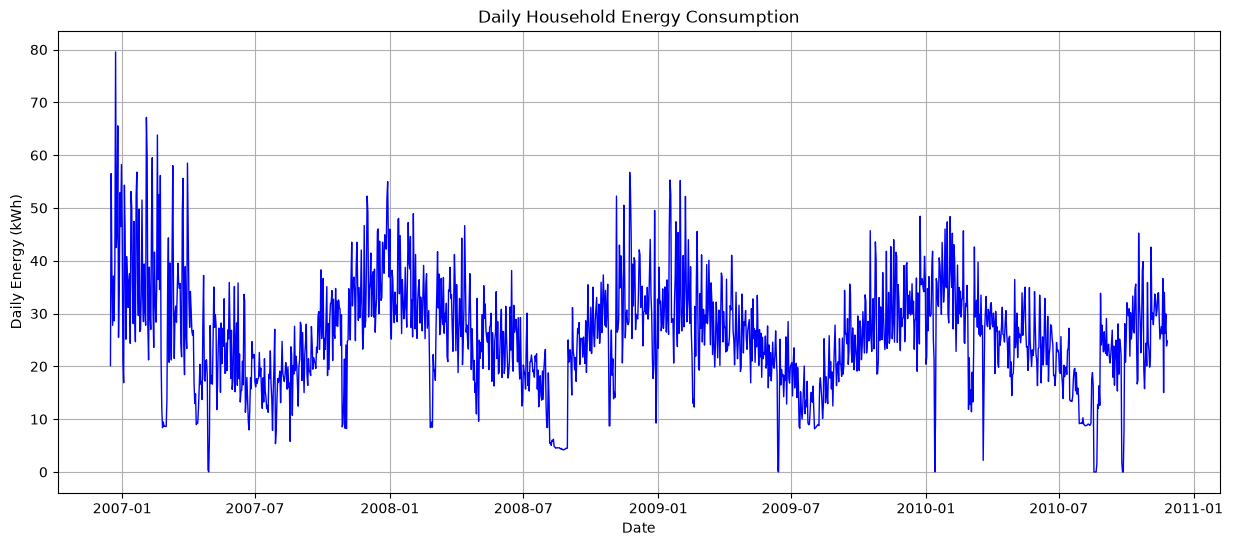

In [21]:
import matplotlib.pyplot as plt

# Plot Daily Energy Consumption
plt.figure(figsize=(15,6))

plt.plot(
    daily_df.index,
    daily_df["Daily_Energy_kWh"],
    color="blue",
    linewidth=1
)

plt.title("Daily Household Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Daily Energy (kWh)")
plt.grid(True)

plt.show()